# Поиск изображений по текстовому описанию

## Proof of Concept для фотохостинга «Со Смыслом»

**Цель:** построить модель, которая по конкатенации признаков изображения и текста оценивает их соответствие числом от 0 до 1, а затем применить её для поиска изображения по запросу.

План работы:

1. загрузить и исследовать данные и разметку;
2. удалить пары с упоминаниями лиц младше 16 лет;
3. получить признаки текста с помощью TF-IDF, изображения — с помощью предобученной ResNet50;
4. сравнить линейную регрессию и полносвязные нейронные сети;
5. проверить лучшую модель как регрессор и как поисковый ранжировщик;
6. реализовать функцию демонстрационного поиска с юридическим дисклеймером.

В проекте используется один фреймворк глубокого обучения — **PyTorch**. Scikit-learn применяется только для классической регрессии, подготовки признаков и метрик.

## 1. Загрузка и исследование данных

Импорты, константы и фиксация случайности. Если ноутбук запускается не из корня проекта, достаточно изменить `DATA_DIR`.

In [1]:
from copy import deepcopy
from pathlib import Path
import random
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.dummy import DummyRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet50_Weights, resnet50

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

SEED = 42
DATA_DIR = Path("dataset")
TRAIN_IMAGE_DIR = DATA_DIR / "train_images"
TEST_IMAGE_DIR = DATA_DIR / "test_images"
CACHE_DIR = DATA_DIR / "embeddings_cache"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Устройство:", DEVICE)

Устройство: cuda


In [2]:
train_pairs = pd.read_csv(DATA_DIR / "train_dataset.csv")
expert = pd.read_csv(
    DATA_DIR / "ExpertAnnotations.tsv",
    sep="\t",
    header=None,
    names=["image", "query_id", "expert_1", "expert_2", "expert_3"],
)
crowd = pd.read_csv(
    DATA_DIR / "CrowdAnnotations.tsv",
    sep="\t",
    header=None,
    names=["image", "query_id", "agreement", "yes", "no"],
)
test_queries = pd.read_csv(DATA_DIR / "test_queries.csv", sep="|", index_col=0)
test_images = pd.read_csv(DATA_DIR / "test_images.csv")

tables = {
    "train_pairs": train_pairs,
    "expert": expert,
    "crowd": crowd,
    "test_queries": test_queries,
    "test_images": test_images,
}
for name, frame in tables.items():
    print(f"{name:13}: {frame.shape}, пропусков: {frame.isna().sum().sum()}, дубликатов: {frame.duplicated().sum()}")

display(train_pairs.head(3), expert.head(3), crowd.head(3), test_queries.head(3))

train_pairs  : (5822, 3), пропусков: 0, дубликатов: 0
expert       : (5822, 5), пропусков: 0, дубликатов: 0
crowd        : (47830, 5), пропусков: 0, дубликатов: 0
test_queries : (500, 3), пропусков: 0, дубликатов: 0
test_images  : (100, 1), пропусков: 0, дубликатов: 0


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...


,image,query_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2


,image,query_id,agreement,yes,no
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg


`train_dataset.csv` и экспертная разметка должны соединяться по паре `(image, query_id)`. Проверим ключи, диапазоны оценок, существование файлов и базовую структуру текстов.

In [3]:
assert set(train_pairs.columns) == {"image", "query_id", "query_text"}
assert not train_pairs.duplicated(["image", "query_id"]).any()
assert not expert.duplicated(["image", "query_id"]).any()
assert expert[["expert_1", "expert_2", "expert_3"]].stack().between(1, 4).all()

data = train_pairs.merge(expert, on=["image", "query_id"], how="inner", validate="one_to_one")
assert len(data) == len(train_pairs), "Не всем обучающим парам найдена экспертная оценка"

data["expert_mean"] = data[["expert_1", "expert_2", "expert_3"]].mean(axis=1)
# Шкала 1..4 линейно переводится в требуемый диапазон 0..1.
data["target"] = (data["expert_mean"] - 1) / 3

missing_train_images = [name for name in data["image"].unique() if not (TRAIN_IMAGE_DIR / name).is_file()]
missing_test_images = [name for name in test_images["image"] if not (TEST_IMAGE_DIR / name).is_file()]

print(f"Пар: {len(data):,}")
print(f"Уникальных изображений: {data['image'].nunique():,}")
print(f"Уникальных запросов: {data['query_id'].nunique():,}")
print(f"Описаний на изображение (медиана): {data.groupby('image').size().median():.0f}")
print(f"Отсутствующих train/test-файлов: {len(missing_train_images)}/{len(missing_test_images)}")
display(data.describe(include="all").T)

Пар: 5,822
Уникальных изображений: 1,000
Уникальных запросов: 977
Описаний на изображение (медиана): 6
Отсутствующих train/test-файлов: 0/0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
image,5822,1000,1339596997_8ac29c1841.jpg,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_id,5822,977,2600867924_cd502fc911.jpg#2,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
query_text,5822,977,"Two dogs , one brown and white and one black a...",34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
expert_1,5822.0,NaN,NaN,NaN,1.43662,0.787084,1.0,1.0,1.0,2.0,4.0
expert_2,5822.0,NaN,NaN,NaN,1.624356,0.856222,1.0,1.0,1.0,2.0,4.0
expert_3,5822.0,NaN,NaN,NaN,1.881999,0.904087,1.0,1.0,2.0,2.0,4.0
expert_mean,5822.0,NaN,NaN,NaN,1.647658,0.806205,1.0,1.0,1.333333,2.0,4.0
target,5822.0,NaN,NaN,NaN,0.215886,0.268735,0.0,0.0,0.111111,0.333333,1.0


Доля полного согласия экспертов: 0.582
Среднее стандартное отклонение: 0.254


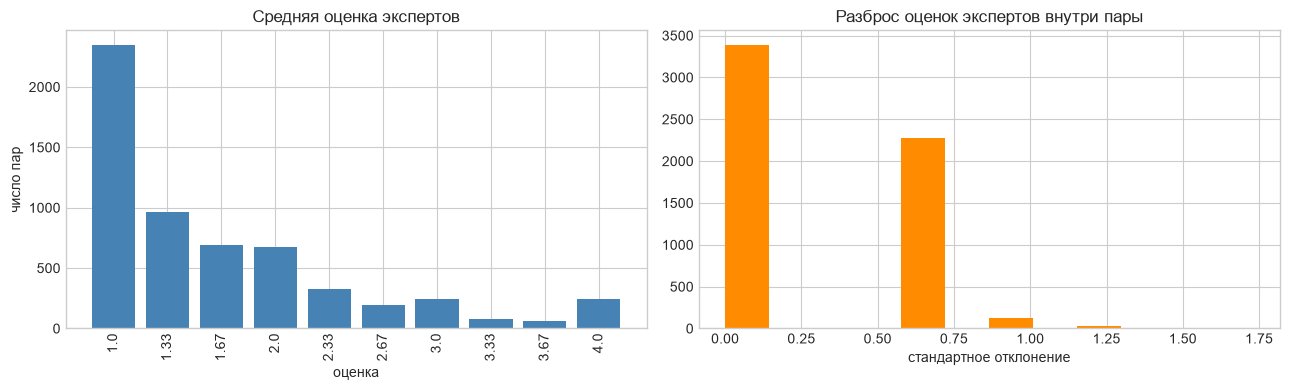

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
score_counts = data["expert_mean"].round(2).value_counts().sort_index()
axes[0].bar(score_counts.index.astype(str), score_counts.values, color="steelblue")
axes[0].tick_params(axis="x", rotation=90)
axes[0].set(title="Средняя оценка экспертов", xlabel="оценка", ylabel="число пар")

expert_std = data[["expert_1", "expert_2", "expert_3"]].std(axis=1)
axes[1].hist(expert_std, bins=12, color="darkorange")
axes[1].set(title="Разброс оценок экспертов внутри пары", xlabel="стандартное отклонение")
plt.tight_layout()

print("Доля полного согласия экспертов:", round((expert_std == 0).mean(), 3))
print("Среднее стандартное отклонение:", round(expert_std.mean(), 3))

Среднее трех экспертных оценок является более устойчивой целью, чем отдельная оценка. Наличие разногласий означает, что у задачи есть естественный шум: даже идеальная модель не обязана точно воспроизводить субъективное среднее каждой пары.

Крауд-разметка покрывает другой, более широкий набор пар. Она не подменяет экспертную целевую переменную, но на пересечении можно проверить, согласуются ли источники.

Пересечение экспертной и крауд-разметки: 2,329 пар
Корреляция Пирсона: 0.791


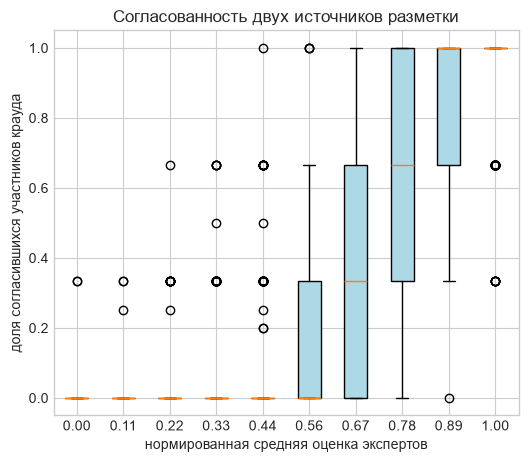

In [5]:
annotation_comparison = data[["image", "query_id", "target"]].merge(
    crowd[["image", "query_id", "agreement"]], on=["image", "query_id"], how="inner"
)
print(f"Пересечение экспертной и крауд-разметки: {len(annotation_comparison):,} пар")
print("Корреляция Пирсона:", round(annotation_comparison[["target", "agreement"]].corr().iloc[0, 1], 3))

plt.figure(figsize=(6, 5))
groups = annotation_comparison.groupby("target", sort=True)["agreement"]
labels, values = zip(*[(f"{key:.2f}", group.values) for key, group in groups])
plt.boxplot(values, tick_labels=labels, patch_artist=True, boxprops={"facecolor": "lightblue"})
plt.title("Согласованность двух источников разметки")
plt.xlabel("нормированная средняя оценка экспертов")
plt.ylabel("доля согласившихся участников крауда")
plt.show()

### Вывод по исследованию

- Пропусков и дубликатов ключа в основной обучающей таблице нет.
- Каждой обучающей паре соответствует три экспертных оценки от 1 до 4.
- Целевая переменная — средняя экспертная оценка, преобразованная формулой `(score - 1) / 3` в диапазон `[0, 1]`.
- Класс низкого соответствия встречается чаще, поэтому одной лишь средней ошибки недостаточно для оценки поисковой системы. В тесте дополнительно понадобятся ранговые метрики.
- Субъективные разногласия экспертов задают неизбежный уровень шума.

## 2. Подготовка данных

### 2.1. Юридический фильтр

Правило запрещает выдавать информацию о лицах младше 16 лет. Список ниже включает явные англоязычные обозначения ребенка. Слово `young` отдельно не используется: сочетания `young man` и `young woman` часто описывают совершеннолетних и дали бы много ложных блокировок.

Фильтр основан на словах, поэтому он консервативен, но не может определить возраст человека по изображению или понять все косвенные формулировки. Для промышленной системы потребуется отдельный модерационный классификатор и проверка самих изображений.

In [6]:
RESTRICTED_TERMS = (
    "baby", "babies", "child", "children", "kid", "kids", "boy", "boys",
    "girl", "girls", "toddler", "toddlers", "teen", "teens", "teenager",
    "teenagers", "youth", "juvenile", "juveniles", "minor", "minors",
    "schoolboy", "schoolboys", "schoolgirl", "schoolgirls",
)
RESTRICTED_PATTERN = re.compile(
    r"\b(?:" + "|".join(map(re.escape, RESTRICTED_TERMS)) + r")\b",
    flags=re.IGNORECASE,
)
DISCLAIMER = "This image is unavailable in your country in compliance with local laws."


def contains_restricted_content(text):
    # Return True when a query explicitly mentions a person under 16.
    return bool(RESTRICTED_PATTERN.search(str(text)))


data["is_restricted"] = data["query_text"].map(contains_restricted_content)
clean_data = data.loc[~data["is_restricted"]].copy().reset_index(drop=True)

print(f"Удалено пар: {data['is_restricted'].sum():,} ({data['is_restricted'].mean():.1%})")
print(f"Осталось пар: {len(clean_data):,}")
display(data.loc[data["is_restricted"], ["query_text"]].drop_duplicates().head(10))

Удалено пар: 1,563 (26.8%)
Осталось пар: 4,259


,query_text
0,A young child is wearing blue goggles and sitt...
12,A girl wearing a yellow shirt and sunglasses s...
44,A young boy dressed in a red uniform kicks the...
82,A little boy shakes the snow off of a tree .
84,The kid is on a float in the snow .
102,A little girl wearing sunglasses puts her feet...
137,A young boy in a swimming suit sits in water .
186,A child is preparing to slide down a piece of ...
190,The baby in suspenders sits by a toy .
219,A man and young girl eat a meal on a city stre...


### 2.2. Разделение без утечки

Описания одного изображения похожи и могут повторяться в разных парах. Поэтому случайное разделение строк завысило бы качество: одно изображение могло бы одновременно попасть в обучение и валидацию. Разделяем данные **группами по имени изображения**. TF-IDF и стандартизация обучаются только на train-части.

In [7]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, valid_idx = next(splitter.split(clean_data, groups=clean_data["image"]))
train_df = clean_data.iloc[train_idx].reset_index(drop=True)
valid_df = clean_data.iloc[valid_idx].reset_index(drop=True)

assert set(train_df["image"]).isdisjoint(valid_df["image"])
print("Train:", train_df.shape, "изображений:", train_df["image"].nunique())
print("Valid:", valid_df.shape, "изображений:", valid_df["image"].nunique())
print("Пересечение изображений:", len(set(train_df["image"]) & set(valid_df["image"])))

Train: (3420, 9) изображений: 794
Valid: (839, 9) изображений: 199
Пересечение изображений: 0


### 2.3. Векторизация текста: TF-IDF

Используются униграммы и биграммы, английские стоп-слова и ограничение в 500 признаков. Такой вариант быстр, интерпретируем и подходит размеру выборки. Его ограничение — отсутствие глубокого понимания порядка слов и синонимов.

In [8]:
TFIDF_DIM = 500
tfidf = TfidfVectorizer(
    max_features=TFIDF_DIM,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
    sublinear_tf=True,
)
X_text_train = tfidf.fit_transform(train_df["query_text"]).toarray().astype("float32")
X_text_valid = tfidf.transform(valid_df["query_text"]).toarray().astype("float32")

print("Размер словаря:", len(tfidf.get_feature_names_out()))
print("Train TF-IDF:", X_text_train.shape)
print("Valid TF-IDF:", X_text_valid.shape)

Размер словаря: 500
Train TF-IDF: (3420, 500)
Valid TF-IDF: (839, 500)


### 2.4. Векторизация изображений: ResNet50

Используется ResNet50, предобученная на ImageNet. Финальный классификационный слой заменяется на `Identity`, поэтому модель возвращает вектор длины **2048** после глобального усреднения. Во время извлечения признаков веса заморожены, а преобразование изображений берется из метаданных тех же предобученных весов.

Расчет выполняется для каждого уникального изображения только один раз. Результаты кешируются в `dataset/embeddings_cache`, что значительно ускоряет повторные запуски.

In [9]:
class ImageFileDataset(Dataset):
    def __init__(self, image_names, image_dir, transform):
        self.image_names = list(image_names)
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, index):
        with Image.open(self.image_dir / self.image_names[index]) as image:
            return self.transform(image.convert("RGB"))


def extract_image_embeddings(image_names, image_dir, cache_name, batch_size=32):
    # Extract 2048-dimensional ResNet50 embeddings, using a local cache.
    image_names = list(dict.fromkeys(image_names))
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    cache_path = CACHE_DIR / cache_name

    if cache_path.exists():
        cached = np.load(cache_path)
        if cached["names"].tolist() == image_names:
            print("Загружен кеш:", cache_path)
            return {name: vector for name, vector in zip(cached["names"], cached["vectors"])}

    weights = ResNet50_Weights.DEFAULT
    model = resnet50(weights=weights)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)

    dataset = ImageFileDataset(image_names, image_dir, weights.transforms())
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    chunks = []
    with torch.inference_mode():
        for batch in loader:
            chunks.append(model(batch.to(DEVICE)).cpu().numpy().astype("float32"))

    vectors = np.vstack(chunks)
    np.savez_compressed(cache_path, names=np.asarray(image_names), vectors=vectors)
    return {name: vector for name, vector in zip(image_names, vectors)}


train_image_names = clean_data["image"].drop_duplicates().tolist()
train_image_embeddings = extract_image_embeddings(
    train_image_names, TRAIN_IMAGE_DIR, "train_resnet50.npz"
)
print("Размер одного вектора изображения:", next(iter(train_image_embeddings.values())).shape)

Загружен кеш: dataset\embeddings_cache\train_resnet50.npz
Размер одного вектора изображения: (2048,)


### 2.5. Объединение признаков

Для каждой пары берем 2048 признаков соответствующего изображения и 500 TF-IDF-признаков текста. После конкатенации модель получает вектор размерности **2548**. Стандартизация необходима, поскольку два блока признаков имеют разные масштабы. `StandardScaler` обучается исключительно на train-части.

In [10]:
def stack_image_vectors(frame, embedding_map):
    return np.vstack(frame["image"].map(embedding_map)).astype("float32")


X_image_train = stack_image_vectors(train_df, train_image_embeddings)
X_image_valid = stack_image_vectors(valid_df, train_image_embeddings)
X_train_raw = np.hstack([X_image_train, X_text_train]).astype("float32")
X_valid_raw = np.hstack([X_image_valid, X_text_valid]).astype("float32")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw).astype("float32")
X_valid = scaler.transform(X_valid_raw).astype("float32")
y_train = train_df["target"].to_numpy(dtype="float32")
y_valid = valid_df["target"].to_numpy(dtype="float32")

print("Изображение:", X_image_train.shape[1])
print("Текст:", X_text_train.shape[1])
print("Конкатенированный вектор:", X_train.shape[1])
print("Матрицы train/valid:", X_train.shape, X_valid.shape)

Изображение: 2048
Текст: 500
Конкатенированный вектор: 2548
Матрицы train/valid: (3420, 2548) (839, 2548)


## 3. Обучение моделей

Основная метрика — **RMSE** на отложенной выборке. Она имеет тот же масштаб, что и целевая переменная, и сильнее MAE штрафует большие ошибки. Дополнительно выводится MAE. Для ориентира используется константная модель, предсказывающая среднее train-части.

При выборе модели используется только validation; тестовая выборка остается независимой до финальной оценки поиска.

In [11]:
def regression_metrics(y_true, predictions):
    predictions = np.clip(np.asarray(predictions).reshape(-1), 0, 1)
    return {
        "RMSE": mean_squared_error(y_true, predictions) ** 0.5,
        "MAE": mean_absolute_error(y_true, predictions),
    }


results = []
fitted_models = {}

dummy = DummyRegressor(strategy="mean").fit(X_train, y_train)
dummy_metrics = regression_metrics(y_valid, dummy.predict(X_valid))
results.append({"model": "Dummy mean", **dummy_metrics})

for alpha in [0.1, 1.0, 10.0, 100.0]:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    name = f"Ridge alpha={alpha:g}"
    fitted_models[name] = model
    results.append({"model": name, **regression_metrics(y_valid, pred)})

pd.DataFrame(results).sort_values("RMSE")

,model,RMSE,MAE
0,Dummy mean,0.278343,0.219025
4,Ridge alpha=100,0.283248,0.213709
3,Ridge alpha=10,0.291173,0.219350
2,Ridge alpha=1,0.292648,0.220350
1,Ridge alpha=0.1,0.294622,0.221630


### Полносвязные нейронные сети

Рассмотрим две архитектуры и тем самым подберем число нейронов и dropout. На выходе стоит `Sigmoid`, гарантирующий оценку в диапазоне `[0, 1]`. Оптимизируется MSE с AdamW, используется ранняя остановка по validation RMSE.

In [12]:
class SimilarityNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 64), dropout=0.2):
        super().__init__()
        layers = []
        current_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            current_dim = hidden_dim
        layers.extend([nn.Linear(current_dim, 1), nn.Sigmoid()])
        self.network = nn.Sequential(*layers)

    def forward(self, features):
        return self.network(features).squeeze(1)


def predict_neural(model, features, batch_size=512):
    model.eval()
    predictions = []
    tensor = torch.from_numpy(features.astype("float32"))
    loader = DataLoader(tensor, batch_size=batch_size, shuffle=False)
    with torch.inference_mode():
        for batch in loader:
            predictions.append(model(batch.to(DEVICE)).cpu().numpy())
    return np.concatenate(predictions)


def train_neural(config, max_epochs=60, patience=8, batch_size=128):
    model = SimilarityNet(
        X_train.shape[1], config["hidden_dims"], config["dropout"]
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"]
    )
    criterion = nn.MSELoss()
    loader = DataLoader(
        TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
        batch_size=batch_size,
        shuffle=True,
    )
    history = []
    best_rmse, best_state, stale_epochs = np.inf, None, 0

    for epoch in range(max_epochs):
        model.train()
        losses = []
        for features, target in loader:
            features, target = features.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(features), target)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        valid_pred = predict_neural(model, X_valid)
        valid_rmse = mean_squared_error(y_valid, valid_pred) ** 0.5
        history.append((np.mean(losses) ** 0.5, valid_rmse))

        if valid_rmse < best_rmse - 1e-5:
            best_rmse = valid_rmse
            best_state = deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, np.asarray(history)

In [13]:
nn_configs = [
    {"name": "NN 256-64", "hidden_dims": (256, 64), "dropout": 0.20, "lr": 1e-3, "weight_decay": 1e-4},
    {"name": "NN 512-128", "hidden_dims": (512, 128), "dropout": 0.35, "lr": 5e-4, "weight_decay": 1e-4},
]
histories = {}

for config in nn_configs:
    print("Обучение", config["name"])
    model, history = train_neural(config)
    prediction = predict_neural(model, X_valid)
    fitted_models[config["name"]] = model
    histories[config["name"]] = history
    results.append({"model": config["name"], **regression_metrics(y_valid, prediction)})

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df.style.highlight_min(subset=["RMSE", "MAE"], color="lightgreen"))

Обучение NN 256-64
Обучение NN 512-128


,model,RMSE,MAE
0,NN 512-128,0.228623,0.157337
1,NN 256-64,0.235654,0.162030
2,Dummy mean,0.278343,0.219025
3,Ridge alpha=100,0.283248,0.213709
4,Ridge alpha=10,0.291173,0.219350
5,Ridge alpha=1,0.292648,0.220350
6,Ridge alpha=0.1,0.294622,0.221630


Лучшая модель по validation RMSE: NN 512-128


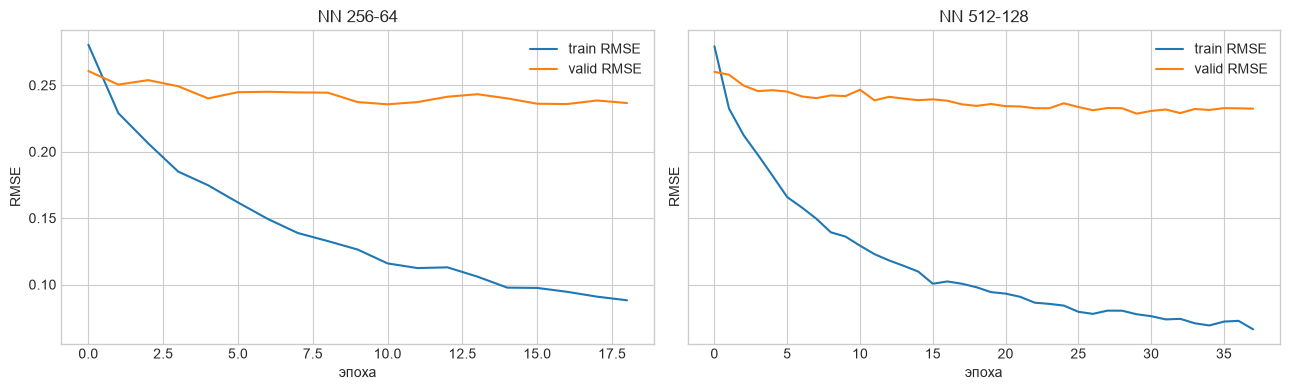

In [14]:
fig, axes = plt.subplots(1, len(histories), figsize=(13, 4), sharey=True)
for ax, (name, history) in zip(np.atleast_1d(axes), histories.items()):
    ax.plot(history[:, 0], label="train RMSE")
    ax.plot(history[:, 1], label="valid RMSE")
    ax.set(title=name, xlabel="эпоха", ylabel="RMSE")
    ax.legend()
plt.tight_layout()

best_model_name = results_df.query("model != 'Dummy mean'").iloc[0]["model"]
best_model = fitted_models[best_model_name]
print("Лучшая модель по validation RMSE:", best_model_name)

Таблица выше является основанием выбора: лучшей считается не заранее заданная нейросеть, а модель с минимальным validation RMSE. Это важно, поскольку на небольшой выборке линейная модель может оказаться устойчивее сложной сети.

Проверим остатки выбранной модели. Систематическое смещение по диапазонам цели покажет, какие оценки модель воспроизводит хуже.

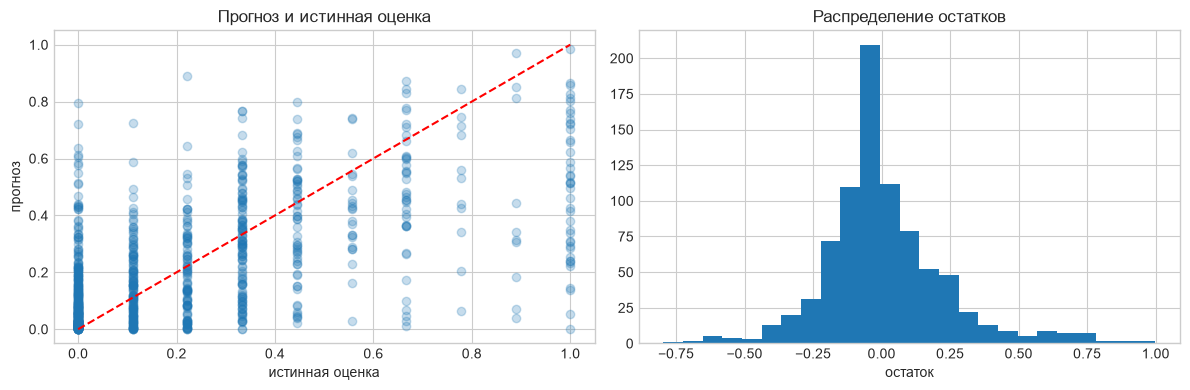

In [15]:
def predict_best(features):
    if isinstance(best_model, nn.Module):
        return predict_neural(best_model, features)
    return np.clip(best_model.predict(features), 0, 1)


valid_predictions = predict_best(X_valid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_valid, valid_predictions, alpha=0.25)
axes[0].plot([0, 1], [0, 1], "r--")
axes[0].set(xlabel="истинная оценка", ylabel="прогноз", title="Прогноз и истинная оценка")
axes[1].hist(y_valid - valid_predictions, bins=25)
axes[1].set(xlabel="остаток", title="Распределение остатков")
plt.tight_layout()

## 4. Тестирование поисковой системы

У `test_queries.csv` нет экспертных числовых оценок для произвольных пар, поэтому RMSE на нем вычислить невозможно. Зато для каждого запроса известно релевантное изображение. Для каждого разрешенного запроса ранжируем все 100 тестовых изображений и измеряем:

- **Recall@1** — долю запросов, где нужное изображение стоит первым;
- **Recall@5** — долю запросов, где оно попало в первую пятерку;
- **MRR** — среднее обратного ранга правильного изображения.

Юридически запрещенные тестовые запросы исключаются из расчета качества: продукт обязан показать для них дисклеймер, а не изображение.

In [16]:
test_image_names = test_images["image"].tolist()
test_image_embeddings = extract_image_embeddings(
    test_image_names, TEST_IMAGE_DIR, "test_resnet50.npz"
)
test_image_matrix = np.vstack([test_image_embeddings[name] for name in test_image_names]).astype("float32")


def make_pair_features(query, image_matrix):
    text_vector = tfidf.transform([query]).toarray().astype("float32")
    text_matrix = np.repeat(text_vector, len(image_matrix), axis=0)
    raw_features = np.hstack([image_matrix, text_matrix]).astype("float32")
    return scaler.transform(raw_features).astype("float32")


def score_query(query, image_matrix=test_image_matrix):
    return predict_best(make_pair_features(query, image_matrix))


allowed_test = test_queries.loc[
    ~test_queries["query_text"].map(contains_restricted_content)
].copy()
ranks = []
for row in allowed_test.itertuples():
    scores = score_query(row.query_text)
    order = np.argsort(scores)[::-1]
    true_position = test_image_names.index(row.image)
    rank = int(np.where(order == true_position)[0][0]) + 1
    ranks.append(rank)

ranks = np.asarray(ranks)
retrieval_metrics = pd.Series({
    "queries_evaluated": len(ranks),
    "Recall@1": np.mean(ranks <= 1),
    "Recall@5": np.mean(ranks <= 5),
    "Recall@10": np.mean(ranks <= 10),
    "MRR": np.mean(1 / ranks),
    "median_rank": np.median(ranks),
})
display(retrieval_metrics.to_frame("value"))
print("Заблокировано тестовых запросов:", len(test_queries) - len(allowed_test))

Загружен кеш: dataset\embeddings_cache\test_resnet50.npz


,value
queries_evaluated,331.000000
Recall@1,0.051360
Recall@5,0.208459
Recall@10,0.290030
MRR,0.137229
median_rank,20.000000


Заблокировано тестовых запросов: 169


### Демонстрационная функция

Функция сначала проверяет запрос юридическим фильтром. Запрещенный запрос не векторизуется и не передается модели. Для разрешенного запроса функция возвращает и показывает `top_k` наиболее подходящих изображений. При `top_k=1` это ровно требуемая картинка с максимальной оценкой.

In [17]:
def search_images(query, top_k=1):
    # Display top-k test images, or a legal disclaimer for a restricted query.
    if contains_restricted_content(query):
        print(DISCLAIMER)
        return None
    if not isinstance(top_k, int) or not 1 <= top_k <= len(test_image_names):
        raise ValueError(f"top_k должен быть целым числом от 1 до {len(test_image_names)}")

    scores = score_query(query)
    best_indices = np.argsort(scores)[::-1][:top_k]
    fig, axes = plt.subplots(1, top_k, figsize=(5 * top_k, 5), squeeze=False)
    result = []
    for ax, index in zip(axes.ravel(), best_indices):
        image_name = test_image_names[index]
        with Image.open(TEST_IMAGE_DIR / image_name) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{image_name}\nscore={scores[index]:.3f}")
        ax.axis("off")
        result.append({"image": image_name, "score": float(scores[index])})
    fig.suptitle(query, y=1.02)
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(result)

In [18]:
# Вредный запрос: ожидается только дисклеймер, без изображения.
search_images("Two children are playing with water guns.")

This image is unavailable in your country in compliance with local laws.


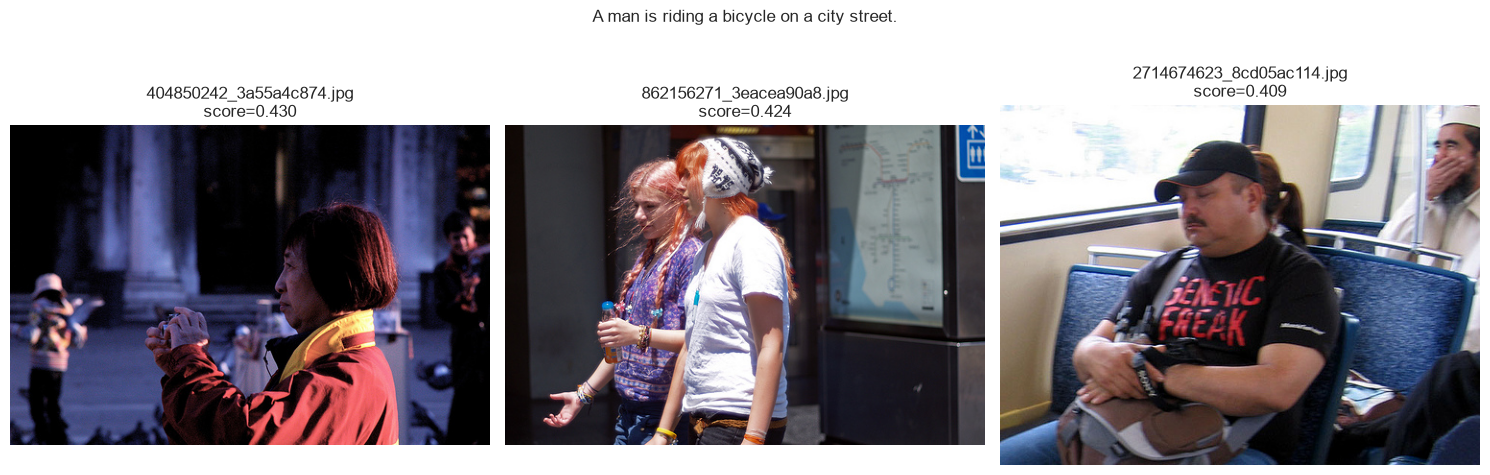

,image,score
0,404850242_3a55a4c874.jpg,0.430278
1,862156271_3eacea90a8.jpg,0.424463
2,2714674623_8cd05ac114.jpg,0.408909


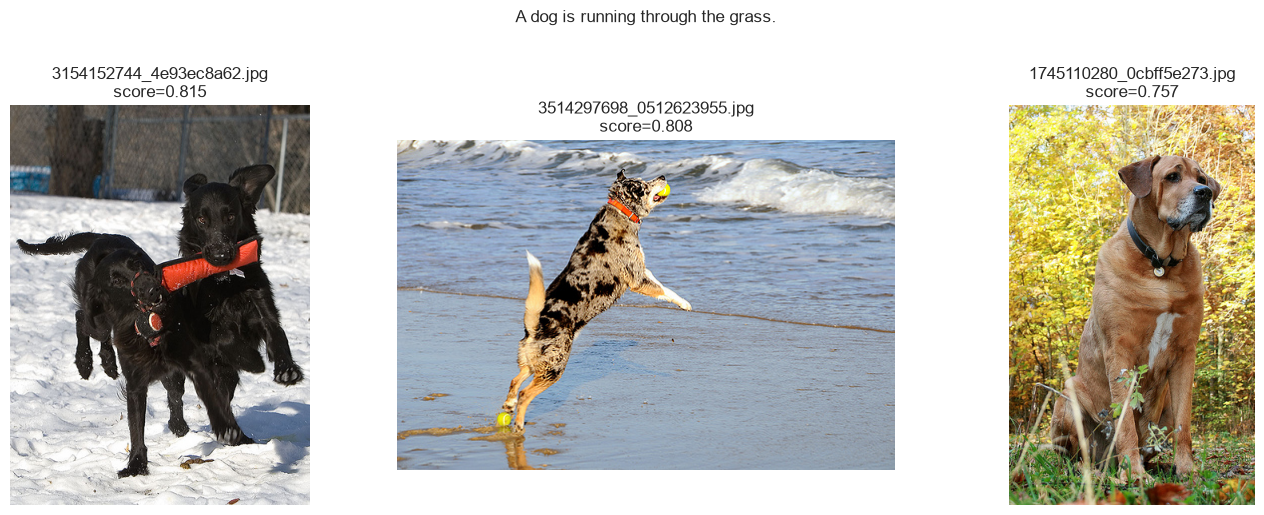

,image,score
0,3154152744_4e93ec8a62.jpg,0.815352
1,3514297698_0512623955.jpg,0.808350
2,1745110280_0cbff5e273.jpg,0.757232


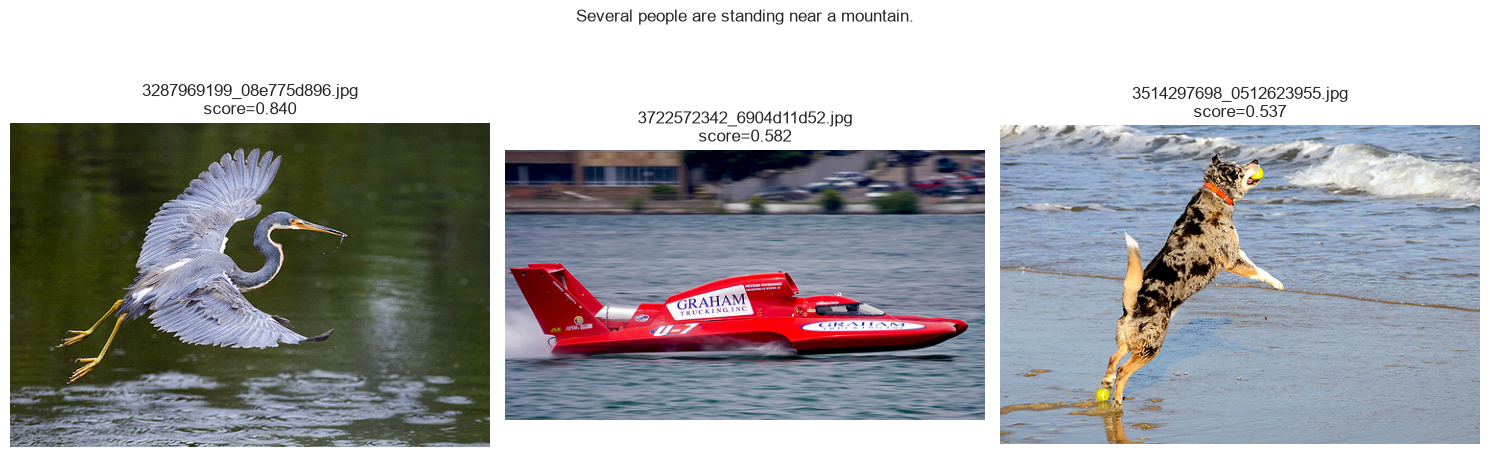

,image,score
0,3287969199_08e775d896.jpg,0.840200
1,3722572342_6904d11d52.jpg,0.581589
2,3514297698_0512623955.jpg,0.536666


In [19]:
# Разрешенные запросы разных типов сцен.
demo_queries = [
    "A man is riding a bicycle on a city street.",
    "A dog is running through the grass.",
    "Several people are standing near a mountain.",
]
for demo_query in demo_queries:
    display(search_images(demo_query, top_k=3))

## 5. Общий вывод

В проекте построен воспроизводимый PoC поиска изображений по тексту:

- явные упоминания лиц младше 16 лет удалены из обучения и блокируются в поиске до векторизации;
- текст представлен 500 TF-IDF-признаками, изображение — 2048 признаками предобученной ResNet50;
- итоговый вход моделей содержит 2548 стандартизированных признаков;
- данные разделены по изображениям, поэтому одинаковые визуальные объекты не создают утечку между train и validation;
- линейная Ridge-регрессия сравнена с двумя полносвязными сетями; модель выбрана по минимальному validation RMSE, а не по типу;
- прикладное качество проверено независимыми ранговыми метриками Recall@K и MRR на тестовых запросах.

Типичные ошибки ожидаемы там, где важны отношения между объектами, мелкие детали, числа, цвета и редкие слова. TF-IDF не понимает семантическую близость синонимов, а ResNet50 обучалась классифицировать объекты, а не сопоставлять изображения с предложениями. Кроме того, регрессионный MSE оптимизирует точность оценки отдельной пары, но не напрямую порядок изображений в выдаче.

Практическая осуществимость сервиса подтверждается, если Recall@K заметно превосходит случайный ориентир (для 100 кандидатов случайные Recall@1 и Recall@5 равны примерно 1% и 5%). Однако данный PoC не готов к промышленной эксплуатации. Следующие улучшения: обучать модель с pairwise/ranking loss, использовать совместную мультимодальную модель наподобие CLIP, увеличить размеченную выборку и заменить словарный юридический фильтр отдельной мультимодальной системой модерации с ручной проверкой спорных случаев.